## Importing Packages

In [1]:
##Installing the Requiremnets
!pip install paddlepaddle-gpu
!pip install paddleocr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 758.9/758.9 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.4/76.4 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.0/78.0 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.3/58.3 kB 6.0 MB/s eta 0:00:00
  Attempting uninstall: opt-einsum
    Found existing installation: opt_einsum 3.4.0
    Uninstalling opt_einsum-3.4.0:
      Successfully uninstalled opt_einsum-3.4.0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 8.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 407.5/407.5 kB 25.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 908.3/908.3 kB 51.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 244.3/244.3 kB 17.3 MB/s eta 0:0

## Importing Packages

In [20]:
##Importing Packages
from paddleocr import PaddleOCR,draw_ocr
import os
import cv2
import matplotlib.pyplot as plt
import re
from PIL import Image
%matplotlib inline

## Create an Object for PaddleOCR

In [21]:
##Init the OCR object
ocr = PaddleOCR(lang='en') # need to run only once to download and load model into memory

[2024/10/07 13:29:37] ppocr DEBUG: Namespace(help='==SUPPRESS==', use_gpu=True, use_xpu=False, use_npu=False, use_mlu=False, ir_optim=True, use_tensorrt=False, min_subgraph_size=15, precision='fp32', gpu_mem=500, gpu_id=0, image_dir=None, page_num=0, det_algorithm='DB', det_model_dir='/root/.paddleocr/whl/det/en/en_PP-OCRv3_det_infer', det_limit_side_len=960, det_limit_type='max', det_box_type='quad', det_db_thresh=0.3, det_db_box_thresh=0.6, det_db_unclip_ratio=1.5, max_batch_size=10, use_dilation=False, det_db_score_mode='fast', det_east_score_thresh=0.8, det_east_cover_thresh=0.1, det_east_nms_thresh=0.2, det_sast_score_thresh=0.5, det_sast_nms_thresh=0.2, det_pse_thresh=0, det_pse_box_thresh=0.85, det_pse_min_area=16, det_pse_scale=1, scales=[8, 16, 32], alpha=1.0, beta=1.0, fourier_degree=5, rec_algorithm='SVTR_LCNet', rec_model_dir='/root/.paddleocr/whl/rec/en/en_PP-OCRv4_rec_infer', rec_image_inverse=True, rec_image_shape='3, 48, 320', rec_batch_num=6, max_text_length=25, rec_ch

## Helper Function

In [27]:
##Writing an Function for the Visualization and the Inference
def save_ocr(ocr,img_path, out_path, result,font):
   # need to run only once to download and load model into memory
  result = ocr.ocr(img_path)
  image = Image.open(img_path).convert('RGB')
  boxes = [line[0] for line in result[0]]
  txts = [line[1][0] for line in result[0]]
  scores = [line[1][1] for line in result[0]]
  im_show = draw_ocr(image, boxes, txts, scores, font_path=font)
  im_show = Image.fromarray(im_show)
  im_show.save('result.jpg')

  plt.figure(figsize=(10, 10))
  plt.imshow(im_show)
  plt.axis('off')  # Hide axis
  plt.show()

## Helper Variables

In [23]:
##Specify the Font and Output Path
out_path = './output_images/result.jpg'
font = '/content/simfang.ttf'

In [24]:
##Image Path -> /MuthuPalaniappan_M_Sem_3.png
img_path = '/content/Cheque309157.jpg'
result = ocr.ocr(img_path)

[2024/10/07 13:29:43] ppocr WARNING: Since the angle classifier is not initialized, it will not be used during the forward process
[2024/10/07 13:29:43] ppocr DEBUG: dt_boxes num : 28, elapsed : 0.047078609466552734
[2024/10/07 13:29:44] ppocr DEBUG: rec_res num  : 28, elapsed : 0.15309476852416992


## Peak View at Resukt

In [25]:
result

[[[[[249.0, 46.0], [645.0, 46.0], [645.0, 96.0], [249.0, 96.0]],
   ('AXIS BANK LTD', 0.9023808240890503)],
  [[[1717.0, 87.0], [1781.0, 87.0], [1781.0, 116.0], [1717.0, 116.0]],
   ('DATE', 0.9984903335571289)],
  [[[261.0, 113.0], [838.0, 113.0], [838.0, 145.0], [261.0, 145.0]],
   ('MEHDIPATNAM,HYDERABAD [AP],HYDERABAD, 500028', 0.9374382495880127)],
  [[[1715.0, 116.0], [1798.0, 116.0], [1798.0, 149.0], [1715.0, 149.0]],
   ('faain', 0.6344691514968872)],
  [[[261.0, 145.0], [520.0, 145.0], [520.0, 176.0], [261.0, 176.0]],
   ('IFS CODE-UTIB0000426', 0.9375065565109253)],
  [[[835.0, 145.0], [1515.0, 145.0], [1515.0, 176.0], [835.0, 176.0]],
   ('VALID FOR THREE MONTHS FROM THE DATE OF ISSUE', 0.9382498264312744)],
  [[[1821.0, 164.0], [1848.0, 164.0], [1848.0, 188.0], [1821.0, 188.0]],
   ('D', 0.971261203289032)],
  [[[1840.0, 159.0], [2257.0, 159.0], [2257.0, 193.0], [1840.0, 193.0]],
   ('DMMYYYY', 0.9551535844802856)],
  [[[805.0, 228.0], [1277.0, 244.0], [1275.0, 309.0], [802

## Segmentation

[2024/10/07 13:31:00] ppocr WARNING: Since the angle classifier is not initialized, it will not be used during the forward process
[2024/10/07 13:31:00] ppocr DEBUG: dt_boxes num : 28, elapsed : 0.03521370887756348
[2024/10/07 13:31:00] ppocr DEBUG: rec_res num  : 28, elapsed : 0.12412190437316895


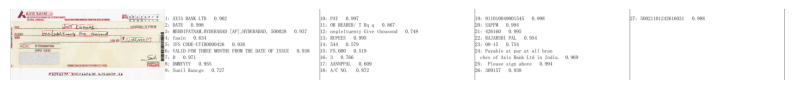

In [28]:
save_ocr(ocr,img_path,out_path,result,font)